# LangGraph: LLM vs RAG Comparison

This notebook builds a LangGraph workflow with **two parallel nodes**:
- **Node 1 — LLM Node**: Answers the question using the model's built-in knowledge
- **Node 2 — RAG Node**: Answers the question by retrieving from a local `.txt` knowledge base

We then compare both answers side by side.


## Step 1: Install Dependencies

In [1]:
import os
import math
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq


In [ ]:
!pip install langgraph langchain langchain-community langchain-google-genai chromadb tiktoken -q
!pip install google-generativeai
!pip install sentence-transformers
!pip install -U langchain-huggingface
!pip install langchain-text-splitters


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


## Step 2: Set Up API Key and LLM

In [7]:
import subprocess
subprocess.run(["pip", "install", "langchain-huggingface"], check=True)


CompletedProcess(args=['pip', 'install', 'langchain-huggingface'], returncode=0)

In [8]:
import subprocess
result = subprocess.run(
    ["uv", "add", "sentence-transformers"],
    capture_output=True, text=True,
    cwd=r"c:\Users\visarati\Desktop\AntiGravity\VS code\AI_agents"
)
print(result.stdout)
print(result.stderr)


Resolved 211 packages in 3ms
Audited 189 packages in 40ms



In [9]:
from dotenv import load_dotenv
import os

load_dotenv()

from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")  # picks up GROQ_API_KEY from .env automatically

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\visarati\Desktop\AntiGravity\VS code\AI_agents\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\visarati\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
import subprocess
result = subprocess.run(["pip", "show", "langchain-huggingface"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


Name: langchain-huggingface
Version: 1.2.2
Summary: An integration package connecting Hugging Face and LangChain.
Home-page: https://docs.langchain.com/oss/python/integrations/providers/huggingface
Author: 
Author-email: 
License: MIT
Location: C:\Users\visarati\AppData\Roaming\Python\Python313\site-packages
Requires: huggingface-hub, langchain-core, tokenizers
Required-by: 




In [12]:
import subprocess
result = subprocess.run(
    ["uv", "add", "langchain-huggingface"],
    capture_output=True, text=True,
    cwd=r"c:\Users\visarati\Desktop\AntiGravity\VS code\AI_agents"
)
print(result.stdout)
print(result.stderr)


Resolved 211 packages in 2ms
Audited 189 packages in 31ms



## Step 3: Build the RAG Retriever from a Text File

We load `knowledge_base.txt`, split it into chunks, embed them into ChromaDB, and create a retriever.

In [13]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

# Load the text file
loader = TextLoader("../data/knowledge_base.txt")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print(f"Total characters: {len(docs[0].page_content)}")

Loaded 1 document(s)
Total characters: 2599


In [14]:
# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=40
)
split_docs = text_splitter.split_documents(docs)

print(f"Split into {len(split_docs)} chunks")
print("\n--- Sample Chunk ---")
print(split_docs[0].page_content)

Split into 19 chunks

--- Sample Chunk ---
LangGraph is a library built on top of LangChain for building stateful, multi-actor applications with LLMs. It enables the creation of agent and multi-agent workflows using graph-based state machines.


In [15]:
import sys
!{sys.executable} -m pip install chromadb

'c:\Users\visarati\Desktop\AntiGravity\VS' is not recognized as an internal or external command,
operable program or batch file.


In [16]:
import subprocess
subprocess.run(["pip", "install", "chromadb"], check=True)


CompletedProcess(args=['pip', 'install', 'chromadb'], returncode=0)

In [18]:
import subprocess
result = subprocess.run(
    ["uv", "add", "chromadb"],
    capture_output=True, text=True,
    cwd=r"c:\Users\visarati\Desktop\AntiGravity\VS code\AI_agents"
)
print(result.stdout)
print(result.stderr)


Resolved 241 packages in 8.05s
   Building ai-agents-learning @ file:///C:/Users/visarati/Desktop/AntiGravity/VS%20code/AI_agents
      Built ai-agents-learning @ file:///C:/Users/visarati/Desktop/AntiGravity/VS%20code/AI_agents
 Downloaded grpcio
 Downloaded onnxruntime
 Downloaded chromadb
Prepared 16 packages in 8.84s
Uninstalled 1 package in 4ms
Installed 30 packages in 1.55s
 ~ ai-agents-learning==0.1.0 (from file:///C:/Users/visarati/Desktop/AntiGravity/VS%20code/AI_agents)
 + bcrypt==5.0.0
 + build==1.5.0
 + chromadb==1.5.9
 + durationpy==0.10
 + flatbuffers==25.12.19
 + googleapis-common-protos==1.75.0
 + grpcio==1.80.0
 + httptools==0.7.1
 + importlib-metadata==8.7.1
 + importlib-resources==7.1.0
 + kubernetes==35.0.0
 + mmh3==5.2.1
 + oauthlib==3.3.1
 + onnxruntime==1.26.0
 + opentelemetry-api==1.41.1
 + opentelemetry-exporter-otlp-proto-common==1.41.1
 + opentelemetry-exporter-otlp-proto-grpc==1.41.1
 + opentelemetry-proto==1.41.1
 + opentelemetry-sdk==1.41.1
 + opentelemet

In [20]:
# Embed and store in ChromaDB
vectorstore = Chroma.from_documents(split_docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("Vector store created successfully!")

# Test the retriever
test_query = "What is RAG?"
retrieved = retriever.invoke(test_query)
print(f"\nTest retrieval for: '{test_query}'")
print(f"Retrieved {len(retrieved)} chunks")
print("\nTop chunk:")
print(retrieved[0].page_content)

Vector store created successfully!

Test retrieval for: 'What is RAG?'
Retrieved 3 chunks

Top chunk:
RAG stands for Retrieval-Augmented Generation. It is a technique where an LLM is augmented with a retrieval system that fetches relevant documents before generating a response. This allows the model


## Step 4: Define the AgentState

The state is shared across all nodes in the graph. It carries the question, and both answers.

In [21]:
from typing import TypedDict

class AgentState(TypedDict):
    question: str
    llm_answer: str
    rag_answer: str
    comparison: str

print("AgentState defined with keys: question, llm_answer, rag_answer, comparison")

AgentState defined with keys: question, llm_answer, rag_answer, comparison


## Step 5: Define the Node Functions

Each function takes the full `AgentState`, does its job, and returns the updated state.

In [ ]:
# NODE 1: LLM Node 
def llm_node(state: AgentState) -> AgentState:
    """
    Answers the question using the LLM's built-in training knowledge.
    No external documents are used.
    """
    question = state["question"]
    
    prompt = f"""Answer the following question using only your own knowledge.
Be concise and clear. Do not say you cannot answer.

Question: {question}

Answer:"""
    
    response = llm.invoke(prompt)
    state["llm_answer"] = response.content
    
    print("[LLM Node] Done")
    return state


# NODE 2: RAG Node 
def rag_node(state: AgentState) -> AgentState:
    """
    Answers the question using chunks retrieved from knowledge_base.txt.
    The LLM is grounded by the retrieved context.
    """
    question = state["question"]
    
    # Retrieve relevant chunks
    relevant_docs = retriever.invoke(question)
    context = "\n\n".join([doc.page_content for doc in relevant_docs])
    
    prompt = f"""You are a helpful assistant. Use ONLY the context below to answer the question.
If the context doesn't contain enough information, say so.

Context:
{context}

Question: {question}

Answer:"""
    
    response = llm.invoke(prompt)
    state["rag_answer"] = response.content
    
    print("[RAG Node] Done")
    return state


# NODE 3: Compare Node
def compare_node(state: AgentState) -> AgentState:
    """
    Formats the final comparison output of LLM vs RAG answers.
    """
    comparison = f"""
{'='*60}
QUESTION: {state['question']}
{'='*60}

🤖 LLM ANSWER (from model training data):
{'-'*40}
{state['llm_answer']}

📚 RAG ANSWER (from knowledge_base.txt):
{'-'*40}
{state['rag_answer']}
{'='*60}
"""
    state["comparison"] = comparison
    print("[Compare Node] Done")
    return state


print("All 3 node functions defined successfully!")

All 3 node functions defined successfully!


## Step 6: Build the LangGraph Workflow

We connect the nodes: LLM and RAG run **sequentially** (LangGraph's `Graph` is sequential by default), then the compare node collects both results.

In [23]:
from langgraph.graph import StateGraph, END

# Initialize the graph with our state schema
workflow = StateGraph(AgentState)

# Add the three nodes
workflow.add_node("llm_node", llm_node)
workflow.add_node("rag_node", rag_node)
workflow.add_node("compare_node", compare_node)

# Define the edges (execution order)
# llm_node → rag_node → compare_node → END
workflow.add_edge("llm_node", "rag_node")
workflow.add_edge("rag_node", "compare_node")
workflow.add_edge("compare_node", END)

# Set the entry point
workflow.set_entry_point("llm_node")

# Compile the graph
app = workflow.compile()

print("Graph compiled successfully!")

c:\Users\visarati\Desktop\AntiGravity\VS code\AI_agents\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Graph compiled successfully!


## Step 7: Visualize the Graph

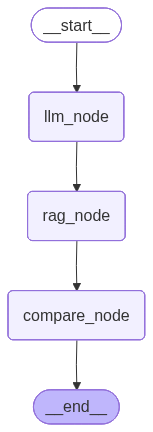

In [24]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph image (install playwright or graphviz for visuals)")
    print("Graph structure:")
    print(app.get_graph().draw_mermaid())

## Step 8: Run the Comparison

Ask any question. The graph will give you both the LLM answer and the RAG answer.

In [ ]:
#Change  question here
question = "What is RAG and how does it work?"

initial_state: AgentState = {
    "question": question,
    "llm_answer": "",
    "rag_answer": "",
    "comparison": ""
}

result = app.invoke(initial_state)
print(result["comparison"])

[LLM Node] Done
[RAG Node] Done
[Compare Node] Done

QUESTION: What is RAG and how does it work?

🤖 LLM ANSWER (from model training data):
----------------------------------------
RAG (Recombination Activating Gene) is a family of enzymes crucial for the process of V(D)J recombination in the immune system. V(D)J recombination is a mechanism by which the immune system generates diversity in antibodies and T-cell receptors.

Here's how it works:

1. The process begins with the assembly of a complex between RAG1 and RAG2 enzymes.
2. This complex recognizes specific DNA sequences, known as recombination signal sequences (RSS), at the ends of variable (V), diversity (D), and joining (J) gene segments.
3. The RAG1-RAG2 complex then makes a double-strand break in the DNA between the gene segment and the RSS.
4. The broken DNA is then processed by two types of enzymes: Artemis and Ku70/Ku80.
5. The Artemis enzyme nicks the broken DNA, while Ku70/Ku80 helps to seal the nick.
6. The broken DNA i

## Step 9: Stream Mode — Watch Each Node Execute

In [26]:
question = "What is LangGraph and what is StateGraph?"

initial_state: AgentState = {
    "question": question,
    "llm_answer": "",
    "rag_answer": "",
    "comparison": ""
}

print(f"Streaming graph execution for: '{question}'\n")

for step_output in app.stream(initial_state):
    for node_name, node_state in step_output.items():
        print(f"\n>>> Output from node: [{node_name}]")
        print("-" * 40)
        if node_name == "llm_node":
            print(f"LLM Answer: {node_state.get('llm_answer', '')}")
        elif node_name == "rag_node":
            print(f"RAG Answer: {node_state.get('rag_answer', '')}")
        elif node_name == "compare_node":
            print(node_state.get('comparison', ''))

Streaming graph execution for: 'What is LangGraph and what is StateGraph?'

[LLM Node] Done

>>> Output from node: [llm_node]
----------------------------------------
LLM Answer: LangGraph and StateGraph are tools used in compiler design.

LangGraph is a visual frontend for language specifications. It allows users to describe the syntax and semantics of a programming language in a graphical interface. This makes it easier to create and manage the language's specification.

StateGraph is used to visualize and analyze the state transitions in a language's semantics. It models the state transitions as a graph, providing a clear and intuitive representation of the language's behavior. This helps in understanding and debugging the language's semantics.

Both LangGraph and StateGraph are part of the Rascal language workbench, which is a tool for designing, specifying, and analyzing programming languages.
[RAG Node] Done

>>> Output from node: [rag_node]
--------------------------------------

## Step 10: Try Multiple Questions in a Loop

In [ ]:
questions = [
    "What is ChromaDB?",
    "How does an agent work in LangGraph?",
    "What is the capital of France?",   # Not in knowledge base 
]

for q in questions:
    state: AgentState = {
        "question": q,
        "llm_answer": "",
        "rag_answer": "",
        "comparison": ""
    }
    result = app.invoke(state)
    print(result["comparison"])
    print("\n")

[LLM Node] Done
[RAG Node] Done
[Compare Node] Done

QUESTION: What is ChromaDB?

🤖 LLM ANSWER (from model training data):
----------------------------------------
ChromaDB is a database of color appearance models. It provides a comprehensive collection of color samples and their corresponding color appearance data across different illuminants and viewing conditions.

📚 RAG ANSWER (from knowledge_base.txt):
----------------------------------------
ChromaDB is a popular open-source vector database used for storing and querying embeddings.



[LLM Node] Done
[RAG Node] Done
[Compare Node] Done

QUESTION: How does an agent work in LangGraph?

🤖 LLM ANSWER (from model training data):
----------------------------------------
In LangGraph, an agent is a basic entity that can perform actions in a graph. It can be viewed as a node or a vertex in the graph, but with the ability to have properties and interact with other agents.

An agent in LangGraph typically has the following characteristics:

---
## Summary

| | LLM Node | RAG Node |
|---|---|---|
| **Source** | Model's training data | Your `knowledge_base.txt` |
| **Grounded?** | No — can hallucinate | Yes — retrieves real chunks |
| **Custom KB?** | No | Yes |
| **Best for** | General knowledge | Domain-specific Q&A |

### Key Concepts Used
- `StateGraph` with typed `AgentState`
- `add_node`, `add_edge`, `set_entry_point`
- `TextLoader` + `RecursiveCharacterTextSplitter` + `Chroma` for RAG
- `app.invoke()` and `app.stream()` for running the graph

---